**Class_1":Handling Missing value**

---



In [ ]:
import seaborn as sns
df=sns.load_dataset('titanic')
df.head()


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


***check missing value***

In [ ]:
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


In [ ]:
#delete the row or data point to handile the missing value
df.shape
#afrer applying dropna
df.dropna().shape


(182, 15)

In [ ]:
#can be columme wise deletion
df.dropna(axis=1)

,survived,pclass,sex,sibsp,parch,fare,class,who,adult_male,alive,alone
0,0,3,male,1,0,7.2500,Third,man,True,no,False
1,1,1,female,1,0,71.2833,First,woman,False,yes,False
2,1,3,female,0,0,7.9250,Third,woman,False,yes,True
3,1,1,female,1,0,53.1000,First,woman,False,yes,False
4,0,3,male,0,0,8.0500,Third,man,True,no,True
...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,0,0,13.0000,Second,man,True,no,True
887,1,1,female,0,0,30.0000,First,woman,False,yes,True
888,0,3,female,1,2,23.4500,Third,woman,False,no,False
889,1,1,male,0,0,30.0000,First,man,True,yes,True


***To handle data by sing imputation techique***

**1.Imputation techque with Mean.It is a importanat for normal distibution**

<Axes: xlabel='age', ylabel='Count'>

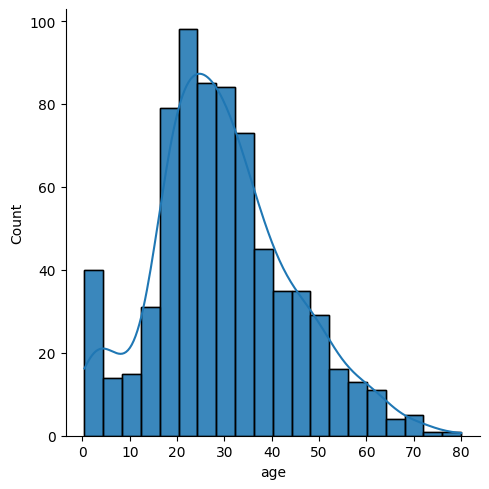

In [ ]:
#imputation with means
sns.displot(df['age'])
sns.histplot(df['age'],kde=True)



In [ ]:
df["age_mean"]=df["age"].fillna(df['age'].mean())
df[['age_mean','age']]

,age_mean,age
0,22.000000,22.0
1,38.000000,38.0
2,26.000000,26.0
3,35.000000,35.0
4,35.000000,35.0
...,...,...
886,27.000000,27.0
887,19.000000,19.0
888,29.699118,NaN
889,26.000000,26.0


**2.Imputation techique with median(its important for out layers)**

In [ ]:
df['age_median']=df['age'].fillna(df['age'].median())
df[['age_median','age_mean','age']]

,age_median,age_mean,age
0,22.0,22.000000,22.0
1,38.0,38.000000,38.0
2,26.0,26.000000,26.0
3,35.0,35.000000,35.0
4,35.0,35.000000,35.0
...,...,...,...
886,27.0,27.000000,27.0
887,19.0,19.000000,19.0
888,28.0,29.699118,NaN
889,26.0,26.000000,26.0


**3.Imputation tecchnique by using mode(this is imporatnat for categorical data)**

In [ ]:
df[df['embarked'].isnull()]

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,age_mean,age_median
61,1,1,female,38.0,0,0,80.0,NaN,First,woman,False,B,NaN,yes,True,38.0,38.0
829,1,1,female,62.0,0,0,80.0,NaN,First,woman,False,B,NaN,yes,True,62.0,62.0


In [ ]:
df['embarked'].unique()

array(['S', 'C', 'Q', nan], dtype=object)

In [ ]:
df['mode_value']=df['embarked'].fillna(df[df['embarked'].notna()]['embarked'].mode()[0]) ## here 0 is the index number of mode
df[["mode_value",'embarked']]


,mode_value,embarked
0,S,S
1,C,C
2,S,S
3,S,S
4,S,S
...,...,...
886,S,S
887,S,S
888,S,S
889,C,C


In [ ]:
df['mode_value'].isnull().sum()

np.int64(0)

In [ ]:
df['embarked'].isnull().sum()

np.int64(2)

**Class_2: Handiling Imbalnaced Dataset:**(for categorical data)

---
1.UpSampling(minority increse)

2.DownSampling(majority decrese)

in two way can handle the imbalance dataset\

In [ ]:
import numpy as np
import pandas as pd
np.random.seed(123)
n_sample=1000
class_0_ratio=0.9
n_class_0=int(n_sample*class_0_ratio)
n_class_1=n_sample-n_class_0


In [ ]:
n_class_0,n_class_1

(900, 100)

In [ ]:
class_0=pd.DataFrame({
    'feature_1':np.random.normal(loc=0,scale=1,size=n_class_0),
    'feature_2':np.random.normal(loc=0,scale=1,size=n_class_0),
    'target':[0]*n_class_0
})

class_1:pd.DataFrame({
    'feature_1':np.random.normal(loc=2,scale=1,size=n_class_1),
    'feture_2':np.random.normal(loc=2,scale=1,size=n_class_1),
    'target':[1]*n_class_1

})

In [ ]:
import numpy as np
import pandas as pd

# Assuming n_class_0 and n_class_1 are already defined in the kernel state
# from previous cells like aExGRmaHaKvB and EBrGB7SYqOBw.

class_0=pd.DataFrame({
    'feature_1':np.random.normal(loc=0,scale=1,size=n_class_0),
    'feature_2':np.random.normal(loc=0,scale=1,size=n_class_0),
    'target':[0]*n_class_0
})

class_1=pd.DataFrame({
    'feature_1':np.random.normal(loc=2,scale=1,size=n_class_1),
    'feture_2':np.random.normal(loc=2,scale=1,size=n_class_1),
    'target':[1]*n_class_1

})

df=pd.concat([class_0,class_1]).reset_index(drop=True)
df.head()

,feature_1,feature_2,target,feture_2
0,-1.085631,0.551302,0,NaN
1,0.997345,0.419589,0,NaN
2,0.282978,1.815652,0,NaN
3,-1.506295,-0.252750,0,NaN
4,-0.578600,-0.292004,0,NaN


In [ ]:
df.tail()

,feature_1,feature_2,target,feture_2
995,1.376371,NaN,1,2.845701
996,2.239810,NaN,1,0.880077
997,1.131760,NaN,1,1.640703
998,2.902006,NaN,1,0.390305
999,2.697490,NaN,1,2.013570


In [ ]:
df['target'].value_counts()

,count
target,
0,900
1,100


In [ ]:
import numpy as np
import pandas as pd

# Define parameters for data generation (from aExGRmaHaKvB)
np.random.seed(123)
n_sample = 1000
class_0_ratio = 0.9
n_class_0 = int(n_sample * class_0_ratio)
n_class_1 = n_sample - n_class_0

# Create class_0 DataFrame
class_0 = pd.DataFrame({
    'feature_1': np.random.normal(loc=0, scale=1, size=n_class_0),
    'feature_2': np.random.normal(loc=0, scale=1, size=n_class_0),
    'target': [0] * n_class_0
})

# Create class_1 DataFrame
class_1 = pd.DataFrame({
    'feature_1': np.random.normal(loc=2, scale=1, size=n_class_1),
    'feture_2': np.random.normal(loc=2, scale=1, size=n_class_1),
    'target': [1] * n_class_1
})

# Concatenate to form df
df = pd.concat([class_0, class_1]).reset_index(drop=True)

#upsampling
df_minority = df[df['target'] == 1]
df_majority = df[df['target'] == 0]

In [ ]:
from sklearn.utils import resample
df_minority_upsampel=resample(df_minority,replace=True, # Sample with replacement
                          n_samples=len(df_majority),
                          random_state=42
                          )

In [ ]:
df_minority_upsampel.shape

(900, 4)

In [ ]:
df_minority_upsampel.head()

,feature_1,feature_2,target,feture_2
951,1.125854,NaN,1,1.843917
992,2.196570,NaN,1,1.397425
914,1.932170,NaN,1,2.998053
971,2.272825,NaN,1,3.034197
960,2.870056,NaN,1,1.550485


In [ ]:
df_upsampled=pd.concat([df_majority,df_minority_upsampel])
df_upsampled['target'].value_counts()

,count
target,
0,900
1,900


***Downsampling***

In [ ]:
from sklearn.utils import resample
df_majority_downsample=resample(df_majority,replace=False,
                                n_samples=len(df_minority),
                                random_state=42
                                )

In [ ]:
df_majority_downsample.shape

(100, 4)

In [ ]:
df_downsampled=pd.concat([df_minority,df_majority_downsample])
df_downsampled.target.value_counts()

,count
target,
1,100
0,100


***Class_3:Handling Imbalance Dataset Using SMOTE***

SMOTE (Synthetic Minority Over-sampling Technique) is a widely used data augmentation method designed to address class imbalance in machine learning. It improves model training by creating "synthetic" examples for the minority class rather than simply duplicating existing ones, which helps prevent overfitting(techique by ***interpolation between existing instance***)

In [ ]:
from sklearn.datasets import make_classification
X,y=make_classification(n_samples=1000,n_redundant=0,n_features=2,n_clusters_per_class=1,weights=[0.90],random_state=12)

In [ ]:
import pandas as pd
df1=pd.DataFrame(X,columns=['f1','f2'])
df2=pd.DataFrame(y,columns=['targes'])
final_df=pd.concat([df1,df2],axis=1)
final_df.head()

,f1,f2,targes
0,-0.762898,-0.706808,0
1,-1.075436,-1.051162,0
2,-0.610115,-0.909802,0
3,-2.023284,-0.428945,1
4,-0.812921,-1.316206,0


In [ ]:
final_df['targes'].value_counts()

,count
targes,
0,900
1,100


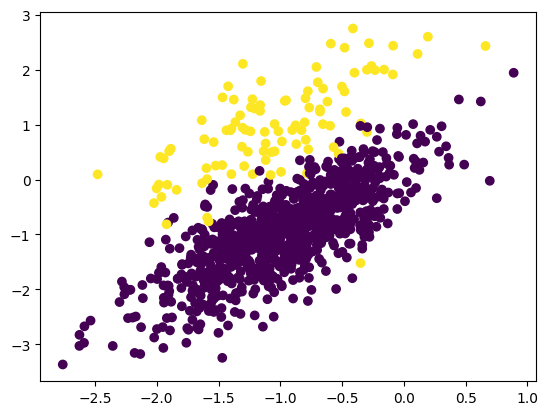

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(final_df['f1'],final_df['f2'],c=final_df['targes'])

In [ ]:
pip install imblearn

In [ ]:
from imblearn.over_sampling import SMOTE
oversample=SMOTE()
X,y=oversample.fit_resample(final_df[['f1','f2']],final_df['targes'])

In [ ]:
X.shape

(1800, 2)

In [ ]:
y.shape

(1800,)

In [ ]:
len(y[y==1])

900

In [ ]:
len(y[y==0])

900

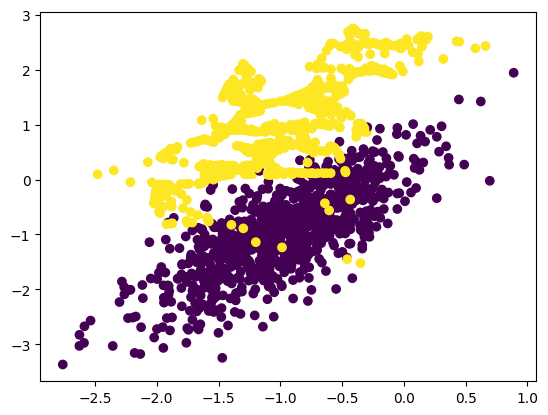

In [ ]:
df1=pd.DataFrame(X,columns=['f1','f2'])
df2=pd.DataFrame({'target': y}) # Correctly create df2 with 'target' column from y
oversample_df=pd.concat([df1,df2],axis=1)
plt.scatter(oversample_df['f1'],oversample_df['f2'],c=oversample_df['target'])

**Class_4:Handling outliers Using Python**

*5 Number Summary and Box Plot*

In [ ]:
##Minimum,Maximum,Median,q1,q3,iqr

In [ ]:
lst_marks=[]

In [ ]:
import random
lst_marks = [random.randint(0, 100) for _ in range(25)]
print(lst_marks)

[10, 51, 27, 45, 60, 42, 49, 8, 54, 51, 25, 83, 41, 14, 70, 36, 47, 81, 10, 56, 15, 74, 63, 69, 78]


In [ ]:
import numpy as np
minimum,Q1,median,Q3,maximum=np.quantile(lst_marks,[0,0.25,0.5,0.75,1.0])

In [ ]:
minimum=np.min(lst_marks)
print(minimum)

8


In [ ]:
print(Q1),print(median),print(Q3),print(maximum)

27.0
49.0
63.0
83.0


(None, None, None, None)

In [ ]:
IQR=Q3-Q1
print(IQR)

36.0


In [ ]:
lower_fence=Q1-1.5*IQR
higer_fence=Q3+1.5*IQR
print(lower_fence)
print(higer_fence)

-27.0
117.0


<Axes: >

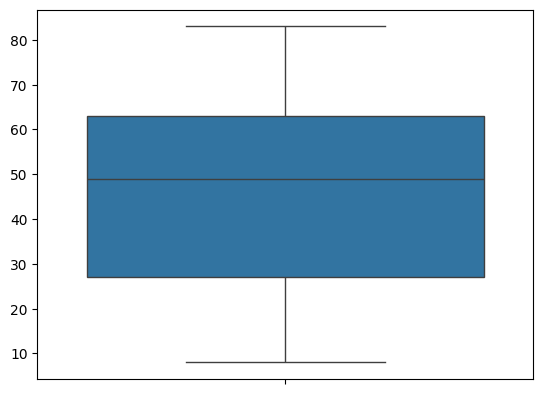

In [ ]:
import seaborn as sns
sns.boxplot(lst_marks)